What is the Iris Dataset?


150 iris flowers with 4 measurements:
  - Sepal length
  - Sepal width
  - Petal length
  - Petal width

3 species (but K-Means doesn't know this):
  - Setosa
  - Versicolor
  - Virginica

Goal: Can K-Means find the 3 species without being told?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')


In [3]:
iris=load_iris()

In [4]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['actual_species'] = iris.target_names[iris.target]  # Add true labels



In [5]:
df.shape

(150, 5)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df['actual_species'].value_counts()

actual_species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
X=df.drop('actual_species',axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

  File "C:\Users\k9481\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\k9481\anaconda3\Lib\subprocess.


Inertias for k=1 to 10:
k=1  →  Inertia: 600.00
k=2  →  Inertia: 222.36
k=3  →  Inertia: 139.82
k=4  →  Inertia: 114.09
k=5  →  Inertia: 90.93
k=6  →  Inertia: 81.54
k=7  →  Inertia: 72.63
k=8  →  Inertia: 62.54
k=9  →  Inertia: 55.12
k=10  →  Inertia: 47.39


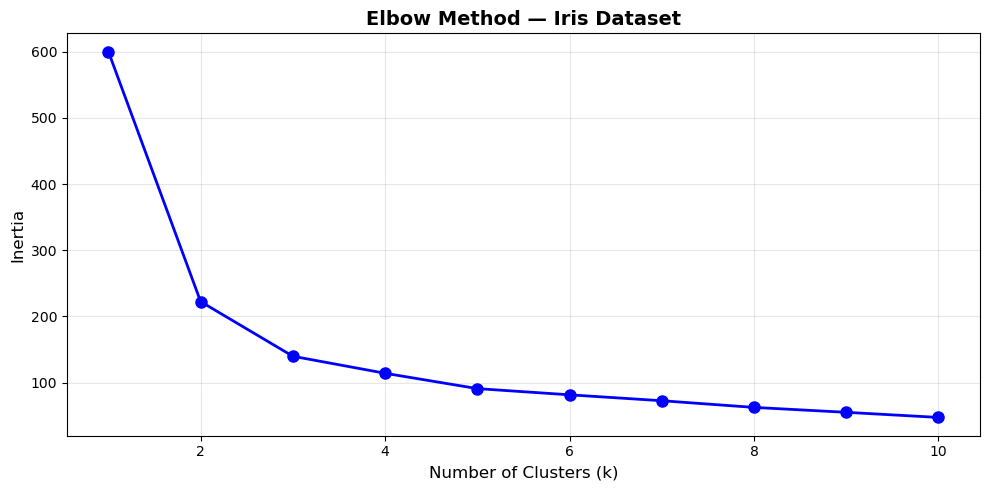

In [9]:

# ═══════════════════════════════════════════════════════════
# STEP 3: Find Optimal K (Elbow Method)
# ═══════════════════════════════════════════════════════════

inertias = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

print("\nInertias for k=1 to 10:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}  →  Inertia: {inertia:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Iris Dataset', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ═══════════════════════════════════════════════════════════
# STEP 4: Train with k=3
# ═══════════════════════════════════════════════════════════

model=KMeans(n_clusters=3,random_state=42,n_init=10)
clusters=model.fit_predict(X_scaled)
df['predicted_clusters']=clusters


In [12]:
print("\n" + "="*60)
print("K-Means Cluster Distribution")
print("="*60)
df['predicted_clusters'].value_counts().sort_index()


K-Means Cluster Distribution


predicted_clusters
0    53
1    50
2    47
Name: count, dtype: int64

In [13]:
centers_original=scaler.inverse_transform(model.cluster_centers_)

In [15]:
print("Features: sepal length, sepal width, petal length, petal width")
for i, center in enumerate(centers_original):
    print(f"Cluster {i}: {center}")

Features: sepal length, sepal width, petal length, petal width
Cluster 0: [5.80188679 2.67358491 4.36981132 1.41320755]
Cluster 1: [5.006 3.428 1.462 0.246]
Cluster 2: [6.78085106 3.09574468 5.5106383  1.97234043]


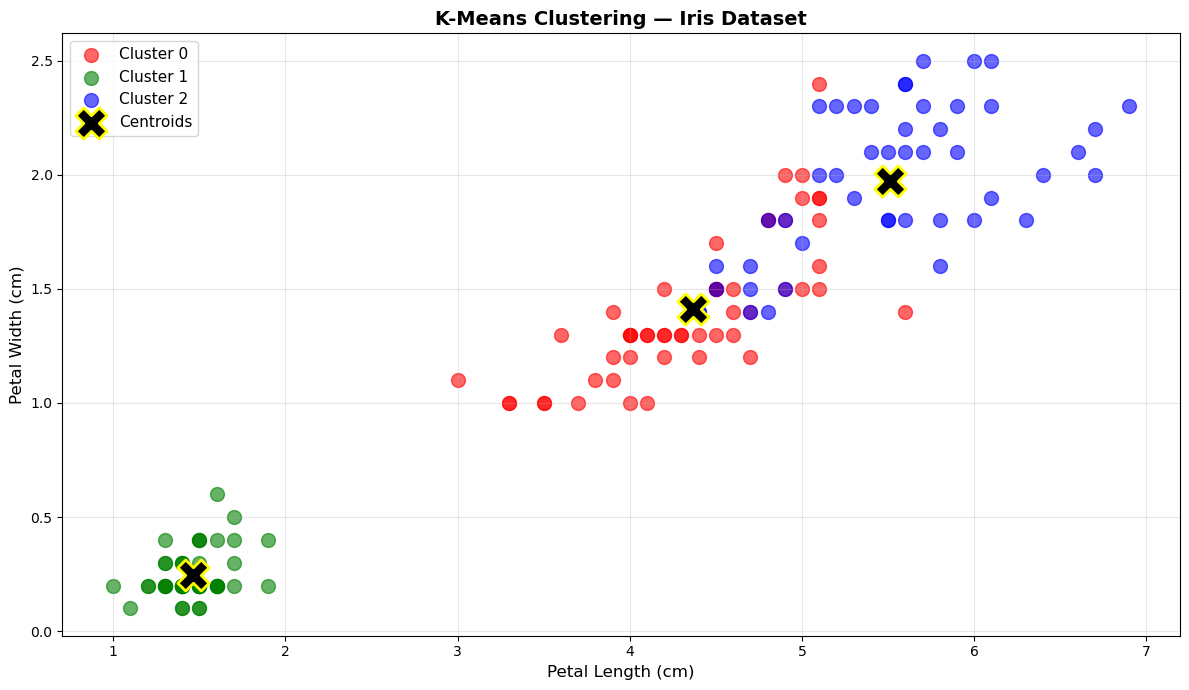

In [17]:

plt.figure(figsize=(12, 7))

colors = ['red', 'green', 'blue']
for cluster_id in range(3):
    mask = df['predicted_clusters'] == cluster_id
    plt.scatter(df[mask]['petal length (cm)'], 
               df[mask]['petal width (cm)'], 
               label=f'Cluster {cluster_id}', 
               s=100, alpha=0.6, color=colors[cluster_id])

# Plot centers
plt.scatter(centers_original[:, 2], centers_original[:, 3], 
           marker='X', s=500, c='black', edgecolors='yellow', 
           linewidth=2, label='Centroids', zorder=5)

plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.title('K-Means Clustering — Iris Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ═══════════════════════════════════════════════════════════
# STEP 7: Compare Predictions with Actual Species
# ═══════════════════════════════════════════════════════════

print("\n" + "="*70)
print("COMPARISON: K-Means vs Actual Species")
print("="*70)

# Create a confusion-like table
comparison = pd.crosstab(df['actual_species'], df['predicted_clusters'], 
                         margins=True, rownames=['Actual Species'], 
                         colnames=['Predicted Clusters'])

print("\nHow many flowers of each species went to each cluster:")
print(comparison)

# Calculate accuracy (roughly)
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("\nDo the clusters match the actual species?")
for cluster_id in range(3):
    cluster_data = df[df['predicted_clusters'] == cluster_id]
    most_common = cluster_data['actual_species'].value_counts().index[0]
    count = cluster_data['actual_species'].value_counts().values[0]
    total = len(cluster_data)
    percentage = (count / total) * 100
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Mostly contains: {most_common} ({count}/{total} = {percentage:.1f}%)")

# ═══════════════════════════════════════════════════════════
# STEP 8: Evaluate Quality
# ═══════════════════════════════════════════════════════════



COMPARISON: K-Means vs Actual Species

How many flowers of each species went to each cluster:
Predicted Clusters   0   1   2  All
Actual Species                     
setosa               0  50   0   50
versicolor          39   0  11   50
virginica           14   0  36   50
All                 53  50  47  150

INTERPRETATION

Do the clusters match the actual species?

Cluster 0:
  Mostly contains: versicolor (39/53 = 73.6%)

Cluster 1:
  Mostly contains: setosa (50/50 = 100.0%)

Cluster 2:
  Mostly contains: virginica (36/47 = 76.6%)


In [21]:

# ═══════════════════════════════════════════════════════════
# STEP 8: Evaluate Quality
# ═══════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CLUSTERING QUALITY METRICS")
print("="*70)
print(f"Inertia: {model.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")

if silhouette_score(X_scaled, clusters) > 0.5:
    print("✓ EXCELLENT clustering!")
elif silhouette_score(X_scaled, clusters) > 0.3:
    print("✓ GOOD clustering!")
else:
    print("⚠ FAIR clustering.")


CLUSTERING QUALITY METRICS
Inertia: 139.82
Silhouette Score: 0.4599
✓ GOOD clustering!
